## Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import optbinning
import pickle
import joblib
import shap

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)
warnings.filterwarnings("ignore")

import sys
sys.path.append("../src")

from data_eda.data_eda import *
from data_eda.plot import * 
from features.features_eng import *
from models.model_training import *
from models.model_analysis import *
from utils.logger import *

(CVXPY) Mar 09 03:03:03 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Mar 09 03:03:03 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
/Users/phupha/Documents/GitHub/credit-score/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read dataset

In [2]:
data_withbin = pd.read_csv("../data/predicted/data10K_Lending_Club_Loans_predicted_bin.csv")
data_withoutbin = pd.read_csv("../data/predicted/data10K_Lending_Club_Loans_predicted.csv")

In [3]:
print(data_withbin.shape)
data_withbin.head(5)

(10000, 14)


,loan_amnt,term,int_rate,grade,annual_inc,verification_status,purpose,inq_last_6mths,revol_util,total_acc,loan_amnt_per_installment,income_to_interest_ratio,is_bad,prediction
0,0.149256,-0.584250,1.078203,0.810092,-0.019761,0.181547,-0.728222,0.140039,0.414956,0.279415,0.03658,0.245598,0,0.095594
1,-0.113627,-0.584250,-0.451049,-0.670379,-0.256405,0.181547,-0.064651,-0.131600,-0.076787,-0.263539,0.03658,-0.765318,0,0.372597
2,0.069937,0.274193,1.078203,0.810092,-0.019761,0.181547,0.327709,0.140039,0.414956,-0.175585,0.03658,0.245598,0,0.031983
3,-0.113627,-0.584250,0.274596,0.226565,-0.019761,0.181547,-0.064651,0.140039,0.175551,0.046724,0.03658,-0.457504,0,0.145763
4,-0.113627,0.274193,0.274596,0.226565,-0.019761,-0.175415,-0.064651,-0.131600,0.175551,0.046724,0.03658,-0.457504,0,0.125066


In [4]:
print(data_withoutbin.shape)
data_withoutbin.head(5)

(10000, 14)


,loan_amnt,term,int_rate,grade,annual_inc,verification_status,purpose,inq_last_6mths,revol_util,total_acc,is_bad,loan_amnt_per_installment,income_to_interest_ratio,prediction
0,4000,60 months,0.0729,A,50000.0,not verified,medical,0.0,12.1,44.0,0,50.150451,12.500000,0.095594
1,16000,60 months,0.1825,F,39216.0,not verified,debt_consolidation,2.0,64.0,5.0,0,39.169604,2.451000,0.372597
2,8700,36 months,0.0788,A,65000.0,not verified,credit_card,0.0,0.6,8.0,0,31.967665,7.471264,0.031983
3,18000,60 months,0.1149,B,57500.0,not verified,debt_consolidation,0.0,37.1,23.0,0,45.479812,3.194444,0.145763
4,16000,36 months,0.1183,B,50004.0,VERIFIED - income,debt_consolidation,4.0,40.4,21.0,0,30.180138,3.125250,0.125066


In [5]:
model = joblib.load("../data/artifacts/logistic_model.pkl")
feature = joblib.load("../data/artifacts/feature_use.pkl")

display(model)
print(feature)

LogisticRegression(C=0.5972793626430583, max_iter=2000, solver='liblinear')

Index(['loan_amnt', 'term', 'int_rate', 'grade', 'annual_inc',
       'verification_status', 'purpose', 'inq_last_6mths', 'revol_util',
       'total_acc', 'loan_amnt_per_installment', 'income_to_interest_ratio'],
      dtype='object')


## Analysis

### SHAP


In [6]:
# explainer = shap.TreeExplainer(model)
explainer = shap.LinearExplainer(model, data_withbin.drop(columns = ['is_bad','prediction']))
shap_values = explainer.shap_values(data_withbin.drop(columns = ['is_bad','prediction']))

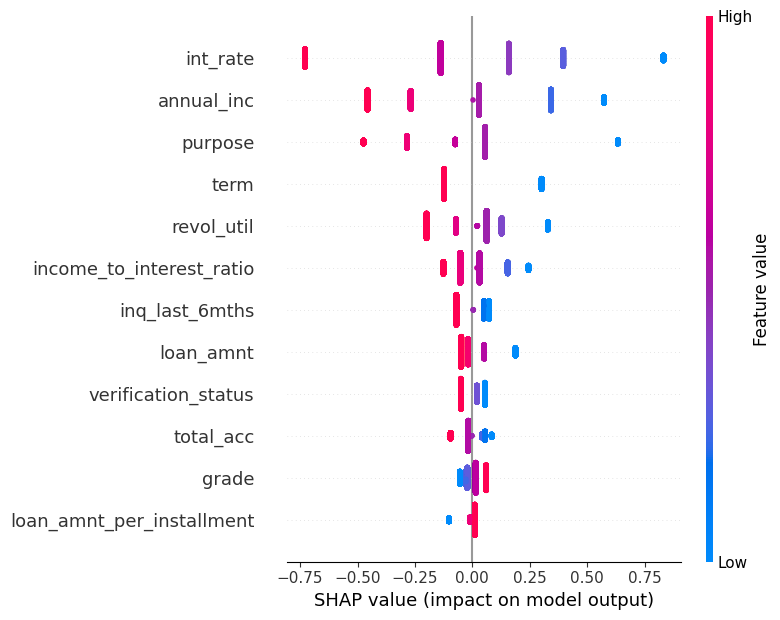

In [7]:
shap.summary_plot(shap_values, data_withbin.drop(columns = ['is_bad','prediction']))

## Bucketing

In [8]:
bucketing = data_withbin[['is_bad','prediction']]

bucketing.head(5)

,is_bad,prediction
0,0,0.095594
1,0,0.372597
2,0,0.031983
3,0,0.145763
4,0,0.125066


In [9]:
binning_process, iv_summary = iv_score(bucketing[['prediction']]
                                        , bucketing['is_bad']
                                        , max_n_bins=10
                                        , min_n_bins=10
                                        , min_bin_size=0.05)

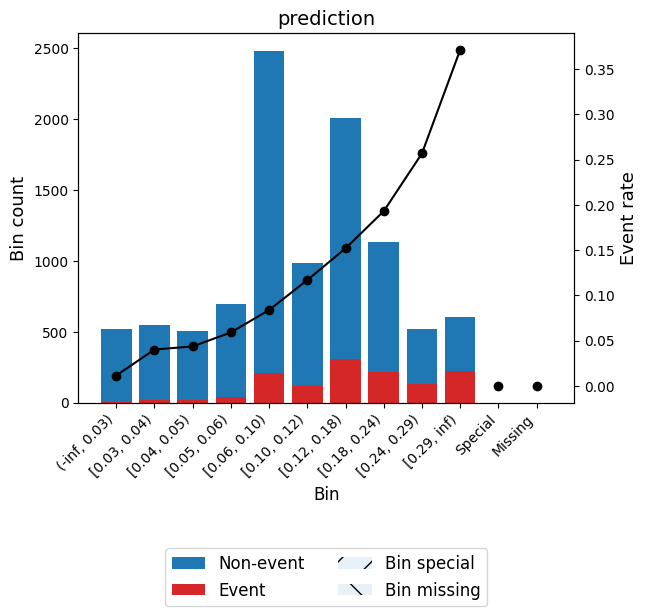

In [10]:
build = binning_process.get_binned_variable('prediction')
bin_df = build.binning_table.build(); bin_df
build.binning_table.plot(metric = 'event_rate', show_bin_labels=True)

In [11]:
bin_df

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.03)",522,0.0522,516,6,0.011494,2.54896,0.139283,0.013840
1,"[0.03, 0.04)",548,0.0548,526,22,0.040146,1.268872,0.055116,0.006462
2,"[0.04, 0.05)",504,0.0504,482,22,0.043651,1.181515,0.045349,0.005360
3,"[0.05, 0.06)",694,0.0694,653,41,0.059078,0.862618,0.037398,0.004535
4,"[0.06, 0.10)",2482,0.2482,2274,208,0.083803,0.486371,0.048934,0.006057
5,"[0.10, 0.12)",984,0.0984,869,115,0.116870,0.117024,0.001290,0.000161
6,"[0.12, 0.18)",2008,0.2008,1703,305,0.151892,-0.185552,0.007401,0.000924
7,"[0.18, 0.24)",1135,0.1135,916,219,0.192952,-0.474442,0.030310,0.003754
8,"[0.24, 0.29)",522,0.0522,388,134,0.256705,-0.842221,0.049609,0.006024
9,"[0.29, inf)",601,0.0601,378,223,0.371048,-1.377664,0.177412,0.020574
